In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

import shap
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
from catboost import CatBoostClassifier

from sklearn.model_selection import StratifiedKFold, cross_validate
from catboost import CatBoostClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)
from sklearn.metrics import precision_score, recall_score, f1_score
import lightgbm as lgb
import lightgbm as lgb
from sklearn.model_selection import train_test_split


/kaggle/input/datasets/nafda1801/british-airways-2/customer_booking.csv


In [2]:
df = pd.read_csv('/kaggle/input/datasets/nafda1801/british-airways-2/customer_booking.csv', encoding='iso-8859-1')

In [3]:
df.head()

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
0,2,Internet,RoundTrip,262,19,7,Sat,AKLDEL,New Zealand,1,0,0,5.52,0
1,1,Internet,RoundTrip,112,20,3,Sat,AKLDEL,New Zealand,0,0,0,5.52,0
2,2,Internet,RoundTrip,243,22,17,Wed,AKLDEL,India,1,1,0,5.52,0
3,1,Internet,RoundTrip,96,31,4,Sat,AKLDEL,New Zealand,0,0,1,5.52,0
4,2,Internet,RoundTrip,68,22,15,Wed,AKLDEL,India,1,0,1,5.52,0


In [4]:
df.shape

(50000, 14)

In [5]:
df.dtypes


num_passengers             int64
sales_channel             object
trip_type                 object
purchase_lead              int64
length_of_stay             int64
flight_hour                int64
flight_day                object
route                     object
booking_origin            object
wants_extra_baggage        int64
wants_preferred_seat       int64
wants_in_flight_meals      int64
flight_duration          float64
booking_complete           int64
dtype: object

In [6]:
df["booking_complete"].value_counts()

booking_complete
0    42522
1     7478
Name: count, dtype: int64

In [7]:
df["lead_stay_interaction"] = (
    df["purchase_lead"] * df["length_of_stay"]
)

df["lead_duration_interaction"] = (
    df["purchase_lead"] * df["flight_duration"]
)

df["stay_duration_interaction"] = (
    df["length_of_stay"] * df["flight_duration"]
)

df["pax_duration_interaction"] = (
    df["num_passengers"] * df["flight_duration"]
)

In [8]:
df["purchase_lead_band"] = pd.cut(
    df["purchase_lead"],
    bins=[-1, 7, 30, 90, 180, float("inf")],
    labels=['oneweek', "onemonth", "threemonth", "sixmonth", "more"]
)

In [9]:
cat_cols = [
    "sales_channel",
    "trip_type",
    "flight_day",
    "route",
    "booking_origin",
    "purchase_lead_band"
]

In [10]:
X = df.drop(columns="booking_complete")
y = df["booking_complete"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [11]:
df.dtypes

num_passengers                  int64
sales_channel                  object
trip_type                      object
purchase_lead                   int64
length_of_stay                  int64
flight_hour                     int64
flight_day                     object
route                          object
booking_origin                 object
wants_extra_baggage             int64
wants_preferred_seat            int64
wants_in_flight_meals           int64
flight_duration               float64
booking_complete                int64
lead_stay_interaction           int64
lead_duration_interaction     float64
stay_duration_interaction     float64
pax_duration_interaction      float64
purchase_lead_band           category
dtype: object

In [12]:
X_train.dtypes

num_passengers                  int64
sales_channel                  object
trip_type                      object
purchase_lead                   int64
length_of_stay                  int64
flight_hour                     int64
flight_day                     object
route                          object
booking_origin                 object
wants_extra_baggage             int64
wants_preferred_seat            int64
wants_in_flight_meals           int64
flight_duration               float64
lead_stay_interaction           int64
lead_duration_interaction     float64
stay_duration_interaction     float64
pax_duration_interaction      float64
purchase_lead_band           category
dtype: object

In [13]:
model1 = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function="Logloss",
    eval_metric="AUC",
    class_weights=[1, 5],
    random_seed=42,
    verbose=False
)

model1.fit(
    X_train,
    y_train,
    cat_features=cat_cols
)

CatBoostClassifier(class_weights=[1, 5], depth=6, eval_metric='AUC', iterations=500, learning_rate=0.05, loss_function='Logloss', random_seed=42, verbose=False)

In [14]:
pred = model1.predict(X_test).ravel()
proba = model1.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, pred))
print("Precision:", precision_score(y_test, pred))
print("Recall   :", recall_score(y_test, pred))
print("F1       :", f1_score(y_test, pred))
print("ROC-AUC  :", roc_auc_score(y_test, proba))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, pred))

Accuracy : 0.7256
Precision: 0.32079264790350376
Recall   : 0.7466577540106952
F1       : 0.44877460827641624
ROC-AUC  : 0.8018969761320247

Confusion Matrix:
[[6139 2365]
 [ 379 1117]]


In [15]:
proba = model1.predict_proba(X_test)[:, 1]

In [16]:
for threshold in [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.50]:

    pred_threshold = (proba >= threshold).astype(int)

    print(
        f"Threshold: {threshold:.2f} | "
        f"Precision: {precision_score(y_test, pred_threshold):.3f} | "
        f"Recall: {recall_score(y_test, pred_threshold):.3f} | "
        f"F1: {f1_score(y_test, pred_threshold):.3f}"
    )

Threshold: 0.10 | Precision: 0.181 | Recall: 0.986 | F1: 0.305
Threshold: 0.15 | Precision: 0.201 | Recall: 0.967 | F1: 0.332
Threshold: 0.20 | Precision: 0.221 | Recall: 0.934 | F1: 0.358
Threshold: 0.25 | Precision: 0.240 | Recall: 0.907 | F1: 0.380
Threshold: 0.30 | Precision: 0.258 | Recall: 0.876 | F1: 0.398
Threshold: 0.35 | Precision: 0.272 | Recall: 0.847 | F1: 0.411
Threshold: 0.40 | Precision: 0.288 | Recall: 0.818 | F1: 0.426
Threshold: 0.50 | Precision: 0.321 | Recall: 0.747 | F1: 0.449


In [17]:
model2 = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.03,
    depth=6,
    loss_function="Logloss",
    eval_metric="AUC",
    auto_class_weights="Balanced",
    random_seed=42,
    verbose=False
)

model2.fit(
    X_train,
    y_train,
    cat_features=cat_cols
)

CatBoostClassifier(auto_class_weights='Balanced', depth=6, eval_metric='AUC', iterations=1000, learning_rate=0.03, loss_function='Logloss', random_seed=42, verbose=False)

In [18]:
proba2 = model2.predict_proba(X_test)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, proba))

ROC-AUC: 0.8018969761320247


In [19]:
importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model2.get_feature_importance()
}).sort_values("importance", ascending=False)

importance

,feature,importance
8,booking_origin,22.002813
7,route,18.541327
15,stay_duration_interaction,6.652906
1,sales_channel,6.145763
4,length_of_stay,6.032272
13,lead_stay_interaction,4.896728
5,flight_hour,4.658423
12,flight_duration,4.371064
14,lead_duration_interaction,4.139338
16,pax_duration_interaction,3.818336


In [20]:
explainer = shap.TreeExplainer(model2)

LightGBM

In [21]:
for col in cat_cols:
    X[col] = X[col].astype("category")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [22]:
model_lgb = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    class_weight={0: 1, 1: 5},
    random_state=42,
    verbosity=-1
)

model_lgb.fit(
    X_train,
    y_train,
    categorical_feature=cat_cols
)

LGBMClassifier(class_weight={0: 1, 1: 5}, learning_rate=0.05, n_estimators=500,
               random_state=42, verbosity=-1)

In [23]:
proba_lgb = model_lgb.predict_proba(X_test)[:, 1]

pred_lgb = (proba_lgb >= 0.5).astype(int)

print("Accuracy :", accuracy_score(y_test, pred_lgb))
print("Precision:", precision_score(y_test, pred_lgb))
print("Recall   :", recall_score(y_test, pred_lgb))
print("F1       :", f1_score(y_test, pred_lgb))
print("ROC-AUC  :", roc_auc_score(y_test, proba_lgb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, pred_lgb))

Accuracy : 0.7622
Precision: 0.33786764705882355
Recall   : 0.6143048128342246
F1       : 0.43595825426944973
ROC-AUC  : 0.7888320721044768

Confusion Matrix:
[[6703 1801]
 [ 577  919]]


In [24]:
for threshold in [0.10, 0.20, 0.30, 0.40, 0.50]:
    pred = (proba_lgb >= threshold).astype(int)

    print(
        f"Threshold: {threshold:.2f} | "
        f"Precision: {precision_score(y_test, pred):.3f} | "
        f"Recall: {recall_score(y_test, pred):.3f} | "
        f"F1: {f1_score(y_test, pred):.3f}"
    )

Threshold: 0.10 | Precision: 0.212 | Recall: 0.938 | F1: 0.345
Threshold: 0.20 | Precision: 0.254 | Recall: 0.865 | F1: 0.393
Threshold: 0.30 | Precision: 0.284 | Recall: 0.784 | F1: 0.417
Threshold: 0.40 | Precision: 0.313 | Recall: 0.703 | F1: 0.433
Threshold: 0.50 | Precision: 0.338 | Recall: 0.614 | F1: 0.436


In [25]:
cat_cols = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.03,
    depth=6,
    loss_function="Logloss",
    class_weights=[1, 5],
    random_seed=42,
    verbose=False
)

In [26]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

results = {
    "accuracy": [],
    "precision": [],
    "recall": [],
    "f1": [],
    "roc_auc": []
}

for fold, (train_idx, val_idx) in enumerate(cv.split(X, y), 1):

    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    model = CatBoostClassifier(
        iterations=1000,
        learning_rate=0.03,
        depth=6,
        loss_function="Logloss",
        class_weights=[1, 5],
        random_seed=42,
        verbose=False
    )

    model.fit(
        X_train,
        y_train,
        cat_features=cat_cols
    )

    # Probability predictions
    proba = model.predict_proba(X_val)[:, 1]

    # Default threshold
    pred = (proba >= 0.5).astype(int)

    results["accuracy"].append(
        accuracy_score(y_val, pred)
    )

    results["precision"].append(
        precision_score(y_val, pred)
    )

    results["recall"].append(
        recall_score(y_val, pred)
    )

    results["f1"].append(
        f1_score(y_val, pred)
    )

    results["roc_auc"].append(
        roc_auc_score(y_val, proba)
    )

    print(f"Fold {fold} complete")

Fold 1 complete
Fold 2 complete
Fold 3 complete
Fold 4 complete
Fold 5 complete


In [27]:
for metric, scores in results.items():
    print(
        f"{metric.upper()}: "
        f"{np.mean(scores):.4f} ± {np.std(scores):.4f}"
    )

ACCURACY: 0.7276 ± 0.0055
PRECISION: 0.3197 ± 0.0043
RECALL: 0.7276 ± 0.0088
F1: 0.4442 ± 0.0035
ROC_AUC: 0.7987 ± 0.0025


In [28]:
final_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.03,
    depth=6,
    loss_function="Logloss",
    class_weights=[1, 5],
    random_seed=42,
    verbose=False
)

final_model.fit(
    X,
    y,
    cat_features=cat_cols
)

CatBoostClassifier(class_weights=[1, 5], depth=6, iterations=1000, learning_rate=0.03, loss_function='Logloss', random_seed=42, verbose=False)

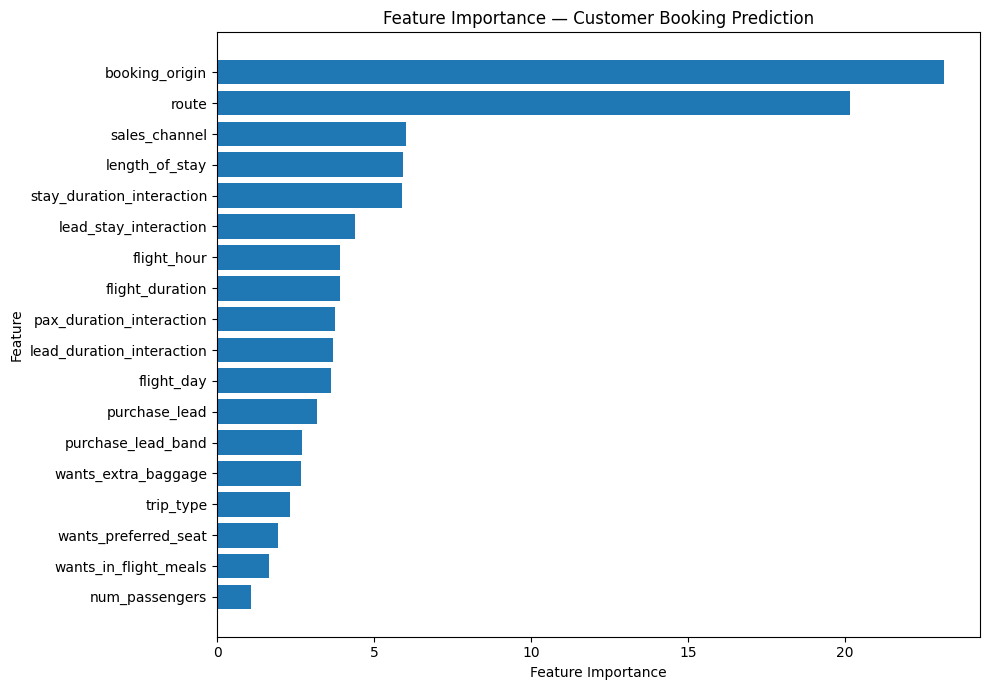

In [29]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": final_model.get_feature_importance()
}).sort_values("Importance", ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(importance["Feature"], importance["Importance"])
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Feature Importance — Customer Booking Prediction")
plt.tight_layout()
plt.show()

In [30]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": final_model.get_feature_importance()
}).sort_values("Importance", ascending=False)

print(importance.round(2))

                      Feature  Importance
8              booking_origin       23.14
7                       route       20.15
1               sales_channel        6.02
4              length_of_stay        5.93
15  stay_duration_interaction        5.89
13      lead_stay_interaction        4.38
5                 flight_hour        3.91
12            flight_duration        3.90
16   pax_duration_interaction        3.75
14  lead_duration_interaction        3.70
6                  flight_day        3.64
3               purchase_lead        3.20
17         purchase_lead_band        2.70
9         wants_extra_baggage        2.68
2                   trip_type        2.31
10       wants_preferred_seat        1.95
11      wants_in_flight_meals        1.67
0              num_passengers        1.09


In [31]:
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X)

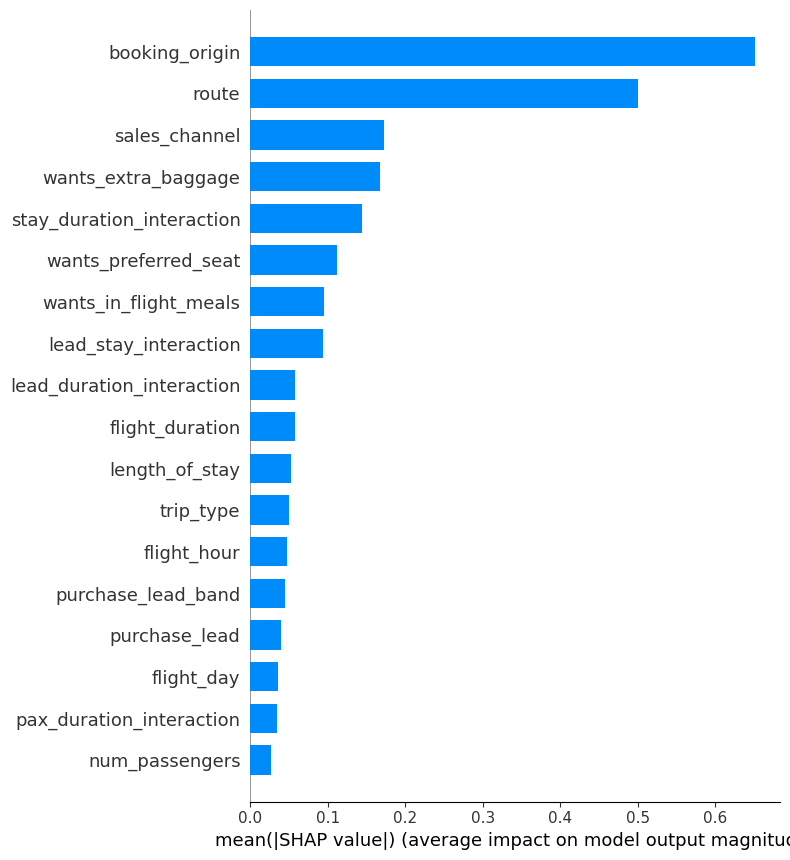

In [32]:
shap.summary_plot(
    shap_values,
    X,
    plot_type="bar"
)

In [33]:
shap_df = pd.DataFrame(
    shap_values,
    columns=X.columns
)

print(shap_df.head())

   num_passengers  sales_channel  trip_type  purchase_lead  length_of_stay  \
0        0.013745       0.122484   0.034688      -0.135792        0.002730   
1        0.017701       0.122260   0.025754      -0.021434       -0.007860   
2        0.018083       0.095877   0.073041      -0.076149       -0.007532   
3        0.014929       0.120117   0.024634      -0.017359       -0.193306   
4        0.008267       0.090760   0.057829      -0.015041        0.002091   

   flight_hour  flight_day     route  booking_origin  wants_extra_baggage  \
0    -0.060953    0.044594 -0.805913       -0.680243             0.122013   
1    -0.054068    0.053947 -0.755550       -0.602863            -0.239877   
2     0.078543    0.020570 -0.813685       -0.505593             0.127651   
3    -0.033578    0.055080 -0.789937       -0.616173            -0.221767   
4     0.023685    0.052186 -0.825854       -0.539825             0.113539   

   wants_preferred_seat  wants_in_flight_meals  flight_duration  \
0

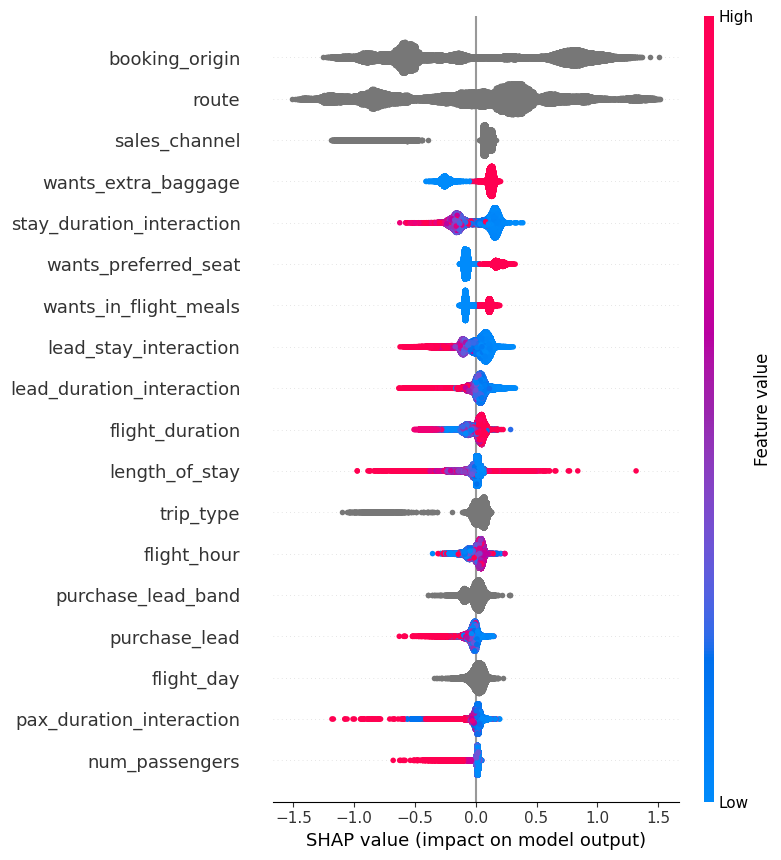

In [34]:
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X)

shap.summary_plot(shap_values, X)